<a href="https://colab.research.google.com/github/yadavrishikesh/Deep-Learning-Slides-Code/blob/main/code/CNN/CNN_real_SpaceTime_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

**CNN for Spatio-Temporal Data Sets**:

Rishikesh Yadav

Assistant professor, IIT Mandi

April 16, 2026

</center>

### Goal
This notebook demonstrates how to apply a Convolutional Neural Network (CNN) for spatio-temporal data, specifically using a 3D CNN (Conv3D) to learn features and make predictions on a real climate dataset.

The main objective is to use past 5 days of Sea Surface Temperature (SST) maps to predict the next day's SST. This approach is realistic because ocean dynamics are relatively slow, spatial patterns are crucial, and temporal evolution plays a significant role.

First, we import the necessary libraries. `numpy` is used for numerical operations, `xarray` for handling labeled multi-dimensional arrays (like our climate data), `matplotlib.pyplot` for plotting, and `tensorflow.keras` for building and training our deep learning model.

Next, we load the Sea Surface Temperature (SST) data from a NOAA OISST v2 high-resolution dataset for the year 2020. The data is accessed directly from a URL using `xarray.open_dataset` which allows for lazy loading and efficient handling of large datasets. We then print the dataset to inspect its structure, dimensions (time, lat, lon), and data variables (sst).

We extract the 'sst' variable from the loaded dataset. This variable contains the actual sea surface temperature values across time, latitude, and longitude. We then print its shape to understand the dimensions of our SST data array.

To focus on a specific region and reduce the computational load, we crop the SST data. Here, we select a smaller spatial region by slicing the latitude and longitude dimensions. This results in a smaller `(time, height, width)` array.

The SST data might contain `NaN` (Not a Number) values, which can cause issues with numerical computations and machine learning models. We convert the `xarray` DataArray to a `numpy` array and replace any `NaN` values with zeros using `np.nan_to_num`. This ensures our data is clean for model training.

To get a visual understanding of the data, we display the first day's SST map using `matplotlib.pyplot.imshow`. This gives us a quick overview of the spatial distribution of sea surface temperatures in the selected region.

Here, we prepare the data for the Conv3D model using a sliding window approach. The goal is to predict the next day's SST based on the previous `window` (5 in this case) days. We create input sequences `X` (5-day stacks) and corresponding target `y` (the 6th day's SST). Each `X` will be a sequence of 5 frames, and each `y` will be the single frame immediately following that sequence.

Convolutional Neural Networks, especially those in Keras, often expect an explicit channel dimension for their inputs. For our grayscale-like SST images, we add a single channel dimension to both `X` and `y` using `[..., None]`. This transforms the shape from `(samples, time_steps, height, width)` to `(samples, time_steps, height, width, channels)` for `X` and `(samples, height, width)` to `(samples, height, width, channels)` for `y`.

We split the prepared data into training and testing sets. Approximately 80% of the data is used for training the model (`X_train`, `y_train`), and the remaining 20% is reserved for evaluating its performance on unseen data (`X_test`, `y_test`). This helps in assessing the generalization capability of the model.

Now, we define the architecture of our Conv3D model using Keras's Sequential API.

*   **`keras.Input(shape=X_train.shape[1:])`**: Defines the input shape for the model, which will be `(5, 60, 60, 1)` (5 time steps, 60x60 spatial resolution, 1 channel).
*   **`layers.Conv3D(16, (3,3,3), padding='same', activation='relu')`**: The first 3D convolutional layer with 16 filters, a 3x3x3 kernel (convolving across time, height, and width), 'same' padding to preserve spatial dimensions, and ReLU activation.
*   **`layers.Conv3D(32, (3,3,3), padding='same', activation='relu')`**: A second 3D convolutional layer with 32 filters, similar to the first.
*   **`layers.Conv3D(1, (window,1,1), activation='linear')`**: A final 3D convolutional layer with 1 filter. The kernel size `(window, 1, 1)` is crucial here. It effectively collapses the time dimension (window=5) into a single output frame, making it a 2D output (height, width, 1 channel). The linear activation is suitable for regression tasks like predicting SST values.
*   **`layers.Reshape((60,60,1))`**: Reshapes the output to match the target shape `(height, width, channels)` for a single SST map.

Before training, we compile the model. We choose the `adam` optimizer, which is an efficient stochastic gradient descent algorithm. The loss function is set to `mse` (Mean Squared Error), which is a common choice for regression problems, measuring the average squared difference between the predicted and actual values.

We train the model using the `fit` method.

*   **`X_train`, `y_train`**: Our training data and their corresponding labels.
*   **`epochs=10`**: The number of times the model will iterate over the entire training dataset.
*   **`batch_size=8`**: The number of samples processed before the model's internal parameters are updated.
*   **`validation_split=0.1`**: 10% of the training data will be held out as a validation set, allowing us to monitor the model's performance on unseen data during training and detect overfitting.

After training, we use the `predict` method to generate SST predictions on the `X_test` dataset. This gives us the model's output for the data it has not seen during training, which we will use to evaluate its generalization performance.

Finally, we visualize the results to compare the model's prediction with the actual next day's SST and the last input day's SST. We plot three images side-by-side for the first sample in our test set:

1.  **Last input day**: The last frame from the input sequence (`X_test[0, -1, :, :, 0]`).
2.  **True next day**: The actual SST map for the day immediately following the input sequence (`y_test[0, :, :, 0]`).
3.  **Predicted next day**: The SST map predicted by our Conv3D model (`pred[0, :, :, 0]`).

This visual comparison helps us qualitatively assess how well the model is performing.

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
url = "https://downloads.psl.noaa.gov/Datasets/noaa.oisst.v2.highres/sst.day.mean.2020.nc"

ds = xr.open_dataset(url)

print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 366, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 2GB ...
Attributes:
    Conventions:    CF-1.5
    title:          NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea Surf...
    institution:    NOAA/National Centers for Environmental Information
    source:         NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface-temp...
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    version:        Version 2.1
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...


In [ ]:
sst = ds['sst']

print(sst.shape)

(366, 720, 1440)


In [ ]:
sst = sst[:, 200:260, 400:460]

print(sst.shape)

(366, 60, 60)


In [ ]:
data = sst.values

# remove NaN
data = np.nan_to_num(data)

print(data.shape)

(366, 60, 60)


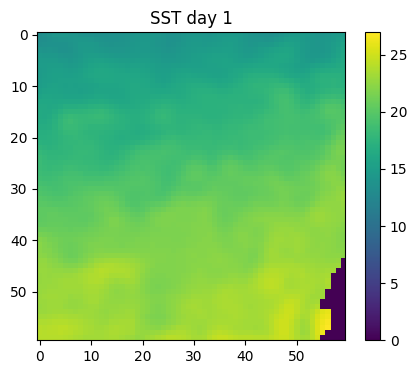

In [ ]:
plt.figure(figsize=(5,4))
plt.imshow(data[0])
plt.title("SST day 1")
plt.colorbar()
plt.show()

In [ ]:
window = 5

X = []
y = []

for t in range(len(data) - window):

    X.append(data[t:t+window])
    y.append(data[t+window])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(361, 5, 60, 60)
(361, 60, 60)


In [ ]:
X = X[..., None]
y = y[..., None]

print(X.shape)

(361, 5, 60, 60, 1)


In [ ]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]

In [ ]:
model = keras.Sequential([
    keras.Input(shape=X_train.shape[1:]),
    layers.Conv3D(
        16,
        (3,3,3),
        padding='same',
        activation='relu'
    ),

    # layers.MaxPooling3D((1,2,2)), # Removed to preserve spatial dimensions

    layers.Conv3D(
        32,
        (3,3,3),
        padding='same',
        activation='relu'
    ),

    layers.Conv3D(
        1,
        (window,1,1),
        activation='linear'
    ),

    layers.Reshape((60,60,1)) # Corrected reshape target to match (height, width, channels) of y_train

])

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=8,
    validation_split=0.1
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 691ms/step - loss: 54.6062 - val_loss: 1.5599
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 649ms/step - loss: 1.1916 - val_loss: 0.4850
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 42s 680ms/step - loss: 0.3783 - val_loss: 0.1644
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 732ms/step - loss: 0.1907 - val_loss: 0.1471
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 25s 764ms/step - loss: 0.1519 - val_loss: 0.0965
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 38s 669ms/step - loss: 0.1445 - val_loss: 0.0922
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 652ms/step - loss: 0.1358 - val_loss: 0.0957
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 683ms/step - loss: 0.1234 - val_loss: 0.0816
Epoch 9/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 641ms/step - loss: 0.1197 - val_loss: 0.0784
Epoch 10/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 49s 883ms/step - loss: 0.1169 - val_loss: 0.0749


In [ ]:
pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 590ms/step


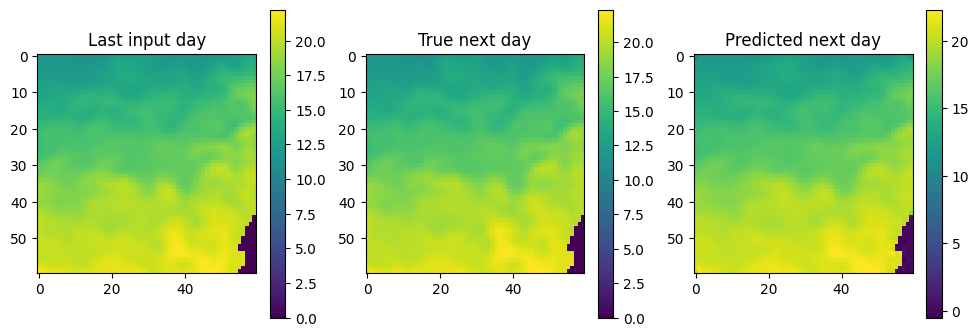

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Last input day")
plt.imshow(X_test[0,-1,:,:,0])
plt.colorbar()

plt.subplot(1,3,2)
plt.title("True next day")
plt.imshow(y_test[0,:,:,0])
plt.colorbar()

plt.subplot(1,3,3)
plt.title("Predicted next day")
plt.imshow(pred[0,:,:,0])
plt.colorbar()

plt.show()